In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# ==========================================
# 2. DATA PREPROCESSING
# ==========================================
# Load built-in MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1 (Critical for CNN convergence)
train_images, test_images = train_images / 255.0, test_images / 255.0

# Reshape data to include the channel dimension (28, 28, 1)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


In [3]:
# ==========================================
# 3. BUILD THE CNN ARCHITECTURE
# ==========================================
model = models.Sequential([
    # First Convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening to 1D for the Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Regularization to prevent overfitting
    layers.Dense(10, activation='softmax') # 10 output units for digits 0-9
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\Harshita\Desktop\ML-DL lab\venv-dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ==========================================
# 4. MODEL TRAINING
# = : =========================================
print("\nTraining CNN on MNIST...")
history = model.fit(train_images, train_labels, epochs=10, 
                    validation_split=0.1, batch_size=64)


Training CNN on MNIST...
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.9268 - loss: 0.2416 - val_accuracy: 0.9820 - val_loss: 0.0630
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.9762 - loss: 0.0793 - val_accuracy: 0.9882 - val_loss: 0.0414
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9828 - loss: 0.0559 - val_accuracy: 0.9878 - val_loss: 0.0403
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9857 - loss: 0.0467 - val_accuracy: 0.9887 - val_loss: 0.0410
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9895 - val_loss: 0.0340
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.9900 - loss: 0.0320 - val_accuracy: 0.9908 - val_loss: 0.0360
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.9913 - loss: 0.0265 - val_accuracy: 0.9882 - val_loss: 0.0409
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9

313/313 - 1s - 4ms/step - accuracy: 0.9917 - loss: 0.0302

Final Test Accuracy: 99.17%


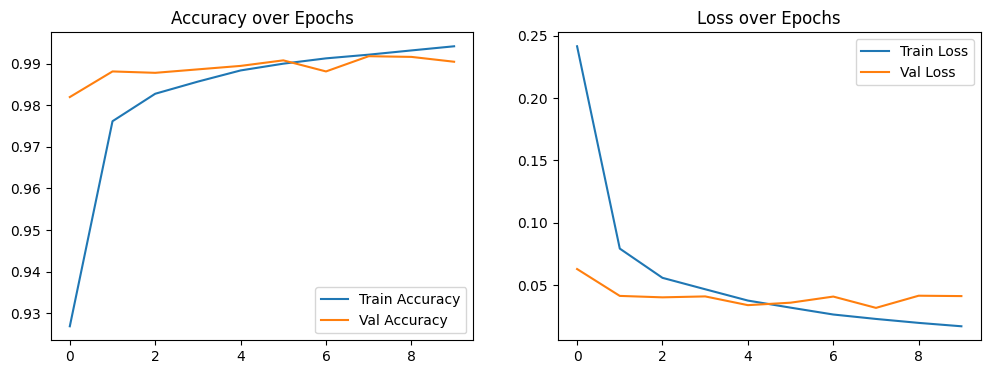

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


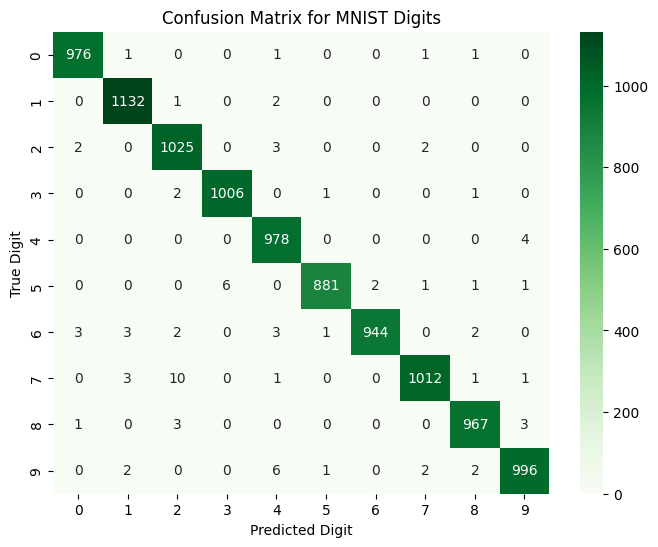


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.98      1.00      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [5]:
# ==========================================
# 5. PERFORMANCE ANALYSIS & VISUALIZATION
# ==========================================
# Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Confusion Matrix
y_pred = np.argmax(model.predict(test_images), axis=1)
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for MNIST Digits')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(test_labels, y_pred))

In [6]:
# ==========================================
# 6. HYPERPARAMETER TUNING WITH KERAS TUNER
# ==========================================
import keras_tuner as kt

# 1. Define the Model Builder Function
# This function tells the tuner which "ranges" to test
def build_tuning_model(hp):
    model = tf.keras.Sequential()
    
    # Tune the number of filters in the first Conv2D layer
    # Try values: 16, 32, 48, 64
    hp_filters = hp.Int('filters_1', min_value=16, max_value=48, step=16)
    model.add(tf.keras.layers.Conv2D(hp_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    model.add(tf.keras.layers.Flatten())
    
    # Tune the number of units in the Dense layer
    hp_units = hp.Int('dense_units', min_value=32, max_value=128, step=32)
    model.add(tf.keras.layers.Dense(units=hp_units, activation='relu'))
    
    # Tune the dropout rate between 0.1 and 0.5
    hp_dropout = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    model.add(tf.keras.layers.Dropout(hp_dropout))
    
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    # Tune the learning rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. Initialize the RandomSearch Tuner
tuner = kt.RandomSearch(
    build_tuning_model,
    objective='val_accuracy',
    max_trials=5, # Try 5 different combinations
    executions_per_trial=1,
    directory='cnn_tuning_dir',
    project_name='mnist_hyperparams'
)

# 3. Run the search
print("\n--- Starting CNN Hyperparameter Search ---")
tuner.search(train_images, train_labels, epochs=3, validation_split=0.1)

# 4. Results Summary
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete.
- Optimal Filters (Layer 1): {best_hps.get('filters_1')}
- Optimal Dense Units: {best_hps.get('dense_units')}
- Optimal Dropout Rate: {best_hps.get('dropout_rate')}
- Optimal Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 5 Complete [00h 05m 58s]
val_accuracy: 0.9901666641235352

Best val_accuracy So Far: 0.9911666512489319
Total elapsed time: 00h 16m 27s

The hyperparameter search is complete.
- Optimal Filters (Layer 1): 32
- Optimal Dense Units: 128
- Optimal Dropout Rate: 0.1
- Optimal Learning Rate: 0.001



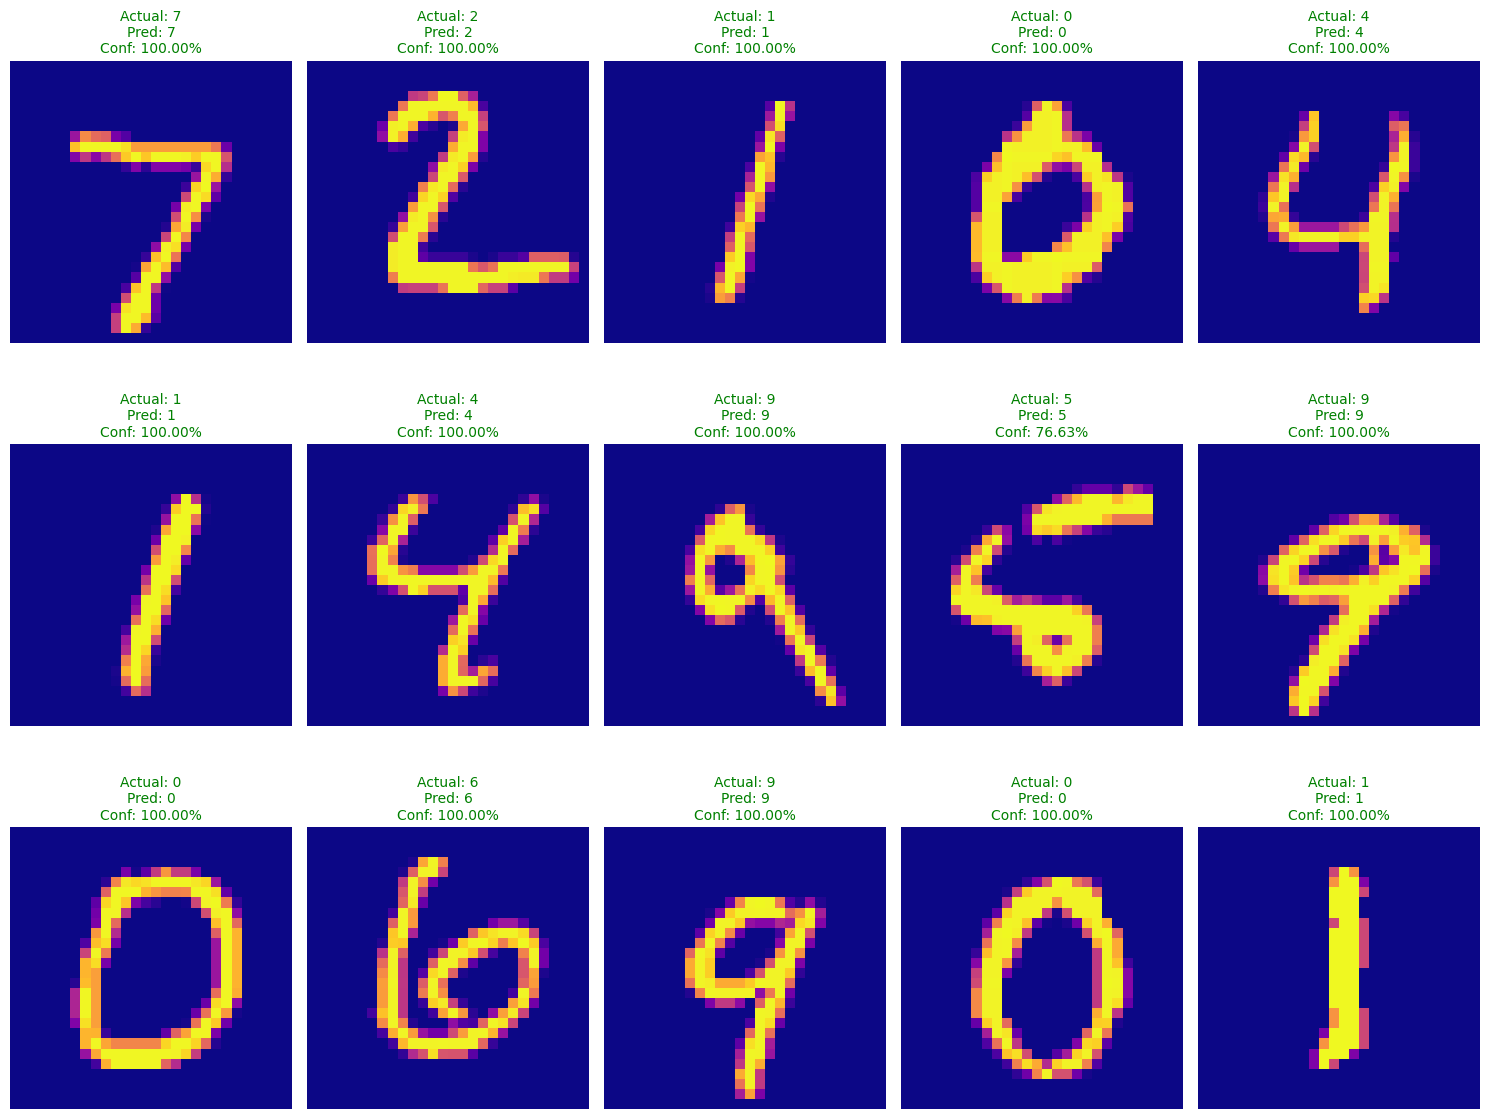

In [7]:
# ==========================================
# 7. VISUALIZING PREDICTIONS & CONFIDENCE
# ==========================================
plt.figure(figsize=(15, 12))

# We use the test set since the model hasn't "seen" these during training
for i in range(15):
    plt.subplot(3, 5, i+1)
    
    # Reshape for display (28x28)
    img_display = test_images[i].reshape(28, 28)
    
    # Get the actual label and our model's prediction
    actual = test_labels[i]
    pred = y_pred[i]
    
    # Calculate Confidence: Get the highest probability from the Softmax output
    # model.predict returns an array of 10 probabilities; np.max finds the highest one.
    prediction_probs = model.predict(test_images[i:i+1], verbose=0)
    confidence = np.max(prediction_probs)
    
    # Plotting
    plt.imshow(img_display, cmap='plasma') 
    
    # Color the title: Green if correct, Red if wrong
    title_color = 'green' if actual == pred else 'red'
    
    plt.title(f"Actual: {actual}\nPred: {pred}\nConf: {confidence:.2%}", 
              color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()